# Module 4 Cross-Region Composite Index

Composite indices are easy to build and mostly indefensible. You normalize some
indicators, pick weights, add them up, and produce a ranking that looks
authoritative and encodes nothing but the analyst's priorities. Every step from
which indicators, which normalization, which weights is a judgment call that
moves the answer, and those calls are usually invisible in the output.

So this module builds the index and then spends most of its length attacking it:

1. Assemble indicators, with orientation made explicit
2. Show that the choice of normalization alone changes the ranking
3. Build the composite under a stated weighting
4. **Monte Carlo over the entire weight simplex** across every defensible
   weighting, how often does each region hold each rank?
5. Decide, from that evidence, whether a composite should be published at all

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from daear_toolkit import climate_access as ca
from daear_toolkit import climate_indicators as ci

# From Module 2. Re-run 02 first if this file is missing.
indicators = pd.read_csv("../outputs/02_hazard_indicators.csv", index_col="region")
indicators

,name,spei_trend,spei_p,vpd_days_trend,vpd_days_p,erc_days_trend,erc_days_p,peak_swe_trend,peak_swe_p,meltout_trend,meltout_p,low_flow_trend,low_flow_p
region,,,,,,,,,,,,,
poudre,Cache la Poudre/Cameron Peak,-0.1029,0.2130,2.1429,0.0024,15.0000,0.0005,-1.2709,0.0247,-8.1250,0.0300,-0.0278,0.8423
black_hills,Black Hills (He Sapa),-0.1114,0.3937,3.3333,0.1357,14.2857,0.0176,-0.9028,0.0408,-0.7512,0.7331,1.8451,0.0608
front_range,Upper South Platte / Front Range foothills,-0.0931,0.2074,3.3333,0.0017,15.0000,0.0003,0.2925,0.6985,-7.1237,0.2151,-2.1029,0.0035


## Orientation 

The single most common way a composite index silently inverts is an indicator
pointing the wrong way, and it is nearly impossible to spot after the fact
because the output still looks plausible.

So orientation is declared explicitly, in a table, before anything is combined:

| Indicator | Raw direction | Needs inversion? |
|---|---|---|
| SPEI trend | more negative = drier = worse | **yes** |
| VPD exceedance days trend | more days = worse | no |
| ERC exceedance days trend | more days = worse | no |
| Peak SWE trend | declining SWE = worse | **yes** |
| Melt-out trend | earlier melt-out = worse | **yes** |
| Low-flow trend | declining low flow = worse | **yes** |

Four of six need inverting. Getting one wrong flips a region's rank.

In [2]:
INDICATOR_COLS = ["spei_trend", "vpd_days_trend", "erc_days_trend",
                  "peak_swe_trend", "meltout_trend", "low_flow_trend"]

INVERT = {
    "spei_trend": True,        # more negative SPEI trend = drying = worse
    "vpd_days_trend": False,   # more fire-weather days = worse
    "erc_days_trend": False,
    "peak_swe_trend": True,    # declining snowpack = worse
    "meltout_trend": True,     # earlier melt-out = worse
    "low_flow_trend": True,    # declining low flow = worse
}

raw = indicators[[c for c in INDICATOR_COLS if c in indicators.columns]].copy()
missing = raw.isna().sum()
if missing.any():
    print("Indicators with missing values (region lacks gauges or stations):")
    print(missing[missing > 0])
    print("\nDropping columns that are not available for all three regions -- imputing")
    print("them would silently invent the comparison this whole module exists to test.")
    raw = raw.dropna(axis=1)

print("\nUsing indicators:", list(raw.columns))
raw


Using indicators: ['spei_trend', 'vpd_days_trend', 'erc_days_trend', 'peak_swe_trend', 'meltout_trend', 'low_flow_trend']


,spei_trend,vpd_days_trend,erc_days_trend,peak_swe_trend,meltout_trend,low_flow_trend
region,,,,,,
poudre,-0.1029,2.1429,15.0000,-1.2709,-8.1250,-0.0278
black_hills,-0.1114,3.3333,14.2857,-0.9028,-0.7512,1.8451
front_range,-0.0931,3.3333,15.0000,0.2925,-7.1237,-2.1029


## Normalization changes the answer

Three defensible normalizations, three different rankings from identical data.
Run them side by side before picking one, because whichever is chosen has to be
reported alongside the result.

- **min-max** is bounded and intuitive, but every score depends on the extremes
  of the sample. With only three regions this is close to degenerate: the worst
  region scores 1.0 and the best scores 0.0 on every indicator *by
  construction*, regardless of whether the gap between them is large or
  trivial. Adding a fourth region rewrites all three existing scores.
- **z-score** preserves relative magnitude and is unbounded, but assumes roughly
  symmetric distributions.
- **rank** is immune to outliers and distribution shape, and discards magnitude
  entirely. With three units it is very coarse but it is honest about how
  little information three units contain.

In [3]:
comparison = {}
for method in ["minmax", "zscore", "rank"]:
    comp = ci.composite_index(raw, method=method, invert=INVERT)
    comparison[method] = comp["composite"]

norm_compare = pd.DataFrame(comparison)
norm_compare["minmax_rank"] = norm_compare["minmax"].rank(ascending=False).astype(int)
norm_compare["zscore_rank"] = norm_compare["zscore"].rank(ascending=False).astype(int)
norm_compare["rank_rank"] = norm_compare["rank"].rank(ascending=False).astype(int)

print(norm_compare.round(3))
agree = (norm_compare["minmax_rank"] == norm_compare["zscore_rank"]).all() and \
        (norm_compare["zscore_rank"] == norm_compare["rank_rank"]).all()
print(f"\nAll three normalizations agree on the ranking: {agree}")
if not agree:
    print("They disagree -- so the ranking is partly an artefact of a methodological")
    print("choice, and no single normalization should be presented on its own.")

             minmax  zscore   rank  minmax_rank  zscore_rank  rank_rank
region                                                                 
poudre        0.668   0.855  0.528            1            1          1
black_hills   0.461   0.382  0.361            3            3          3
front_range   0.644   0.763  0.444            2            2          2

All three normalizations agree on the ranking: True


## The composite, under one stated weighting

Equal weights, chosen and defended rather than defaulted into. Equal weighting
is a real position: it says we have no principled basis for ranking drought
against fire weather against snowpack loss.

Any unequal weighting requires a stated rationale tied to a decision. If the
audience is a municipal water utility, snowpack and low flow plausibly matter
more; if it is a fire district, VPD and ERC do. Both are defensible; neither is
"the" resilience index, and the sensitivity analysis in Step 4 is what makes
that concrete instead of a disclaimer.

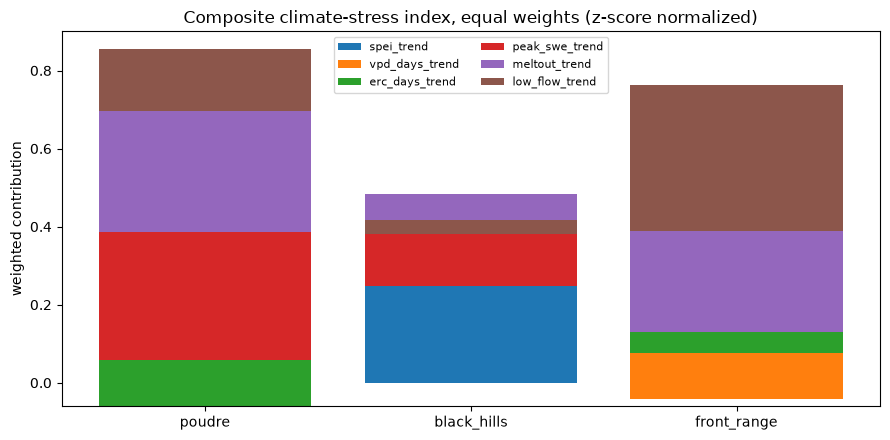

,spei_trend,vpd_days_trend,erc_days_trend,peak_swe_trend,meltout_trend,low_flow_trend,composite,rank
region,,,,,,,,
poudre,1.058,-1.414,0.707,1.965,1.855,0.958,0.855,1
black_hills,2.195,0.707,-1.414,1.413,-0.403,-0.203,0.382,3
front_range,-0.253,0.707,0.707,-0.378,1.548,2.245,0.763,2


In [4]:
composite = ci.composite_index(raw, method="zscore", invert=INVERT)
composite.to_csv("../outputs/03_composite_index.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
comp_cols = [c for c in composite.columns if c not in ("composite", "rank")]
bottom = np.zeros(len(composite))
w = 1.0 / len(comp_cols)
for c in comp_cols:
    vals = composite[c].values * w
    ax.bar(composite.index, vals, bottom=bottom, label=c)
    bottom += vals
ax.set_ylabel("weighted contribution"); ax.set_title("Composite climate-stress index, equal weights (z-score normalized)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("../outputs/03_composite_breakdown.png", dpi=150)
plt.show()

composite.round(3)

## Weight sensitivity

Draw 5,000 weight vectors from a Dirichlet distribution with concentration 1.0,
which is uniform over the entire weight simplex. Every defensible weighting, and
every indefensible one, gets sampled.

Then ask: across all of them, how often does each region hold each rank?

This converts an unanswerable objection ("why those weights?") into a measured
quantity. If a region is top-ranked under 95% of weightings, the specific weights
barely matter and the conclusion is robust. If it is top-ranked under 40%, the
index is reporting the analyst's priorities and should not be published as a
ranking at all.

             P(rank 1)  P(rank 2)  P(rank 3)  mean_score  score_p05  score_p95
region                                                                        
poudre           0.472      0.395      0.133       0.857      0.041      1.441
black_hills      0.138      0.251      0.611       0.383     -0.367      1.134
front_range      0.390      0.354      0.256       0.768      0.205      1.380

Rank stability: 0.49
  > 0.80  ranking is a finding
  0.5-0.8  ranking is weakly supported; report probabilities, not ranks
  < 0.50  ranking is an artefact of the weights; do not publish it as a ranking


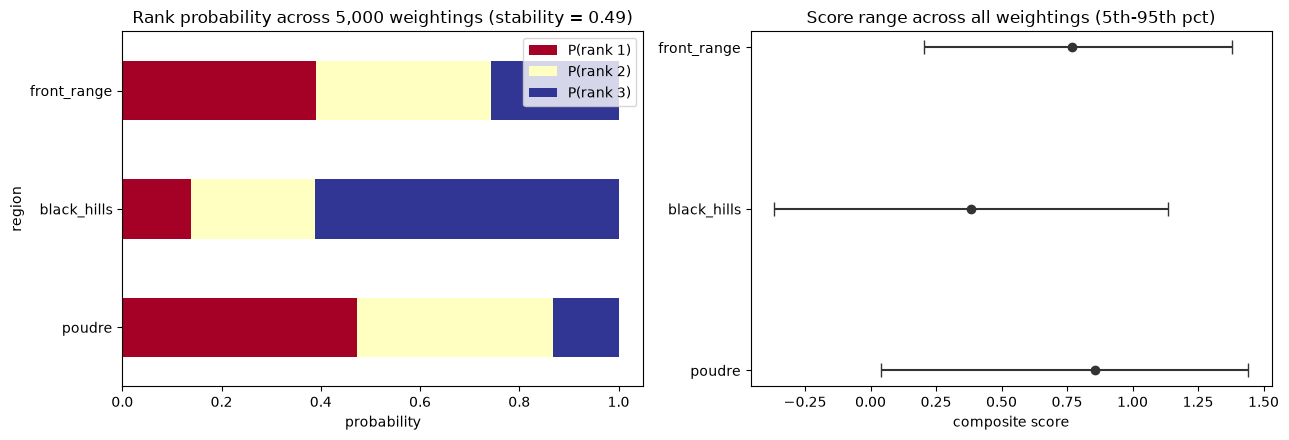

In [5]:
sens = ci.weight_sensitivity(raw, n_draws=5000, method="zscore", invert=INVERT, seed=0)
stability = ci.rank_stability(sens)

print(sens)
print(f"\nRank stability: {stability:.2f}")
print("  > 0.80  ranking is a finding")
print("  0.5-0.8  ranking is weakly supported; report probabilities, not ranks")
print("  < 0.50  ranking is an artefact of the weights; do not publish it as a ranking")

sens.to_csv("../outputs/03_weight_sensitivity.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
prob_cols = [c for c in sens.columns if c.startswith("P(rank")]
sens[prob_cols].plot(kind="barh", stacked=True, ax=axes[0], colormap="RdYlBu")
axes[0].set_title(f"Rank probability across 5,000 weightings (stability = {stability:.2f})")
axes[0].set_xlabel("probability")

axes[1].errorbar(sens["mean_score"], range(len(sens)),
                 xerr=[sens["mean_score"] - sens["score_p05"], sens["score_p95"] - sens["mean_score"]],
                 fmt="o", capsize=5, color="#333")
axes[1].set_yticks(range(len(sens))); axes[1].set_yticklabels(sens.index)
axes[1].set_xlabel("composite score"); axes[1].set_title("Score range across all weightings (5th-95th pct)")
plt.tight_layout()
plt.savefig("../outputs/03_weight_sensitivity.png", dpi=150)
plt.show()

## Which indicators actually drive the ranking?

If two indicators are strongly correlated across regions, they are not
contributing independent information, they are double-weighting the same
signal. With six indicators and three regions this is close to guaranteed, and
it is worth quantifying rather than hoping.

Note the elephant: **three regions is not a sample.** Correlations computed
across three points are not estimates of anything. This step is shown because it
is the right procedure and it scales, not because n=3 supports the conclusion.

In [6]:
norm = pd.DataFrame(
    {c: ci.normalize_indicator(raw[c].values, method="zscore", invert=INVERT.get(c, False)) for c in raw.columns},
    index=raw.index,
)

print(f"n = {len(raw)} regions, {len(raw.columns)} indicators")
print("Correlations across 3 points are descriptive only.\n")
print(norm.corr().round(2))

# Leave-one-out: how much does each indicator matter to the final ranking?
base_rank = ci.composite_index(raw, method="zscore", invert=INVERT)["rank"]
loo = []
for col in raw.columns:
    reduced = raw.drop(columns=col)
    r = ci.composite_index(reduced, method="zscore", invert={k: v for k, v in INVERT.items() if k != col})["rank"]
    loo.append({"dropped": col, "ranking_changed": not (r == base_rank).all(),
                "new_order": " > ".join(r.sort_values().index)})
print()
pd.DataFrame(loo)

n = 3 regions, 6 indicators
Correlations across 3 points are descriptive only.

                spei_trend  vpd_days_trend  erc_days_trend  peak_swe_trend  \
spei_trend            1.00           -0.04           -0.84            0.76   
vpd_days_trend       -0.04            1.00           -0.50           -0.68   
erc_days_trend       -0.84           -0.50            1.00           -0.29   
peak_swe_trend        0.76           -0.68           -0.29            1.00   
meltout_trend        -0.77           -0.60            0.99           -0.17   
low_flow_trend       -1.00            0.03            0.85           -0.75   

                meltout_trend  low_flow_trend  
spei_trend              -0.77           -1.00  
vpd_days_trend          -0.60            0.03  
erc_days_trend           0.99            0.85  
peak_swe_trend          -0.17           -0.75  
meltout_trend            1.00            0.78  
low_flow_trend           0.78            1.00  



,dropped,ranking_changed,new_order
0,spei_trend,True,front_range > poudre > black_hills
1,vpd_days_trend,False,poudre > front_range > black_hills
2,erc_days_trend,False,poudre > front_range > black_hills
3,peak_swe_trend,True,front_range > poudre > black_hills
4,meltout_trend,False,poudre > front_range > black_hills
5,low_flow_trend,True,poudre > black_hills > front_range


## Summary and recommendation

The composite index, with the analysis that determines whether it should be used.

**How to report this, depending on what Step 4 returned:**

- **Stability > 0.8** publish the ranking, alongside the sensitivity figure.
  The specific weights are not doing the work.
- **Stability 0.5–0.8** publish rank *probabilities*, not ranks. "Poudre is
  most stressed under 68% of weightings" is defensible; "Poudre ranks first" is
  not.
- **Stability < 0.5** do not publish a composite. Present the indicators
  separately. The honest finding in that case is that these regions are stressed
  in different ways that do not collapse onto one axis, which is more useful to a
  partner than a false ordering.

**The n=3 problem, stated plainly.** Three regions cannot support correlation
estimates, factor analysis, or any claim about indicator redundancy. The
machinery here is built to scale to 20+ regions, where it becomes genuinely
informative. With three, treat the sensitivity analysis as the finding and the
ranking as provisional.

**Why this module is the differentiator.** Most climate-indicator products stop
at Step 3 and ship the number. Shipping Step 4 alongside it and being willing
to conclude that the index should not be published is what makes the output
trustworthy to a technical reviewer. That is a stronger position in front of an
accelerator panel than a more confident index would be.